In [ ]:
# Install required packages
!pip install librosa tqdm scikit-learn tensorflow matplotlib numpy

# Emotion Detection from Speech using RAVDESS Dataset

This notebook implements a CNN-based emotion detection model using the RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song) dataset.

**Dataset Details:**
- 7356 files from 24 professional actors (12 female, 12 male)
- Emotions: neutral, calm, happy, sad, angry, fearful, disgust, surprised
- Audio format: 16bit, 48kHz .wav files

**Pipeline:**
1. Download and extract the RAVDESS dataset
2. Extract log-mel spectrograms from audio files
3. Train a CNN model for emotion classification
4. Evaluate model performance with privacy-preserving noise injection

## 1. Download and Extract RAVDESS Dataset

In [ ]:
import os

# Define paths
DOWNLOAD_DIR = os.path.expanduser("~/Downloads")
ZIP_PATH = os.path.join(DOWNLOAD_DIR, "ravdess-dataset.zip")
EXTRACT_DIR = os.path.join(DOWNLOAD_DIR, "ravdess-dataset")

# Create download directory if it doesn't exist
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# Download the dataset
if not os.path.exists(ZIP_PATH):
    print("Downloading RAVDESS dataset...")
    !curl -L -o "{ZIP_PATH}" \
      https://www.kaggle.com/api/v1/datasets/download/orvile/ravdess-dataset

    # Check if download succeeded (file should be > 1MB)
    if os.path.exists(ZIP_PATH) and os.path.getsize(ZIP_PATH) > 1_000_000:
        print("Download complete!")
else:
    print(f"Dataset already downloaded at {ZIP_PATH}")

Dataset already downloaded at /root/Downloads/ravdess-dataset.zip


In [ ]:
import zipfile

# Extract the dataset
if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete!")
else:
    print(f"Dataset already extracted at {EXTRACT_DIR}")

# List the contents
print("\nDataset structure:")
for item in os.listdir(EXTRACT_DIR):
    item_path = os.path.join(EXTRACT_DIR, item)
    if os.path.isdir(item_path):
        print(f"  {item}/ ({len(os.listdir(item_path))} items)")

Extracting dataset...
Extraction complete!

Dataset structure:
  Video_Speech_Actor_09/ (1 items)
  Video_Speech_Actor_16/ (1 items)
  Video_Song_Actor_09/ (1 items)
  Video_Speech_Actor_23/ (1 items)
  Video_Song_Actor_02/ (1 items)
  Video_Speech_Actor_21/ (1 items)
  Video_Speech_Actor_07/ (1 items)
  Video_Song_Actor_07/ (1 items)
  Video_Song_Actor_17/ (1 items)
  Video_Speech_Actor_18/ (1 items)
  Video_Song_Actor_24/ (1 items)
  Video_Song_Actor_08/ (1 items)
  Video_Song_Actor_16/ (1 items)
  Video_Song_Actor_12/ (1 items)
  Video_Song_Actor_13/ (1 items)
  Video_Speech_Actor_10/ (1 items)
  Video_Speech_Actor_06/ (1 items)
  Video_Speech_Actor_02/ (1 items)
  Video_Speech_Actor_15/ (1 items)
  Video_Song_Actor_03/ (1 items)
  Video_Song_Actor_11/ (1 items)
  Video_Song_Actor_14/ (1 items)
  Video_Speech_Actor_05/ (1 items)
  Video_Speech_Actor_01/ (1 items)
  Video_Speech_Actor_14/ (1 items)
  Video_Speech_Actor_19/ (1 items)
  Audio_Song_Actors_01-24/ (23 items)
  Video_Song_

## 2. Load and Explore Audio Files

**Filename Convention (7-part identifier):**
- Modality: 01=full-AV, 02=video-only, 03=audio-only
- Vocal channel: 01=speech, 02=song
- Emotion: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised
- Emotional intensity: 01=normal, 02=strong
- Statement: 01="Kids are talking by the door", 02="Dogs are sitting by the door"
- Repetition: 01=1st, 02=2nd
- Actor: 01-24 (odd=male, even=female)

In [ ]:
import glob

# Find the audio speech directory
AUDIO_DIR = os.path.join(EXTRACT_DIR, "Audio_Speech_Actors_01-24")

# If nested differently, search for it
if not os.path.exists(AUDIO_DIR):
    # Search for the directory
    for root, dirs, files in os.walk(EXTRACT_DIR):
        for d in dirs:
            if "Audio_Speech" in d:
                AUDIO_DIR = os.path.join(root, d)
                break

print(f"Audio directory: {AUDIO_DIR}")

# List all WAV files
wav_files = glob.glob(os.path.join(AUDIO_DIR, "Actor_*/*.wav"))
print(f"Total WAV files found: {len(wav_files)}")

# Show sample filenames
if wav_files:
    print("\nSample filenames:")
    for f in wav_files[:3]:
        print(f"  {os.path.basename(f)}")

Audio directory: /root/Downloads/ravdess-dataset/Audio_Speech_Actors_01-24
Total WAV files found: 1440

Sample filenames:
  03-01-07-01-02-01-14.wav
  03-01-03-02-01-02-14.wav
  03-01-03-02-01-01-14.wav


In [ ]:
# Emotion mapping based on RAVDESS filename convention
emotion_dict = {
    1: 'neutral',
    2: 'calm',
    3: 'happy',
    4: 'sad',
    5: 'angry',
    6: 'fearful',
    7: 'disgust',
    8: 'surprised'
}

def get_emotion_from_filename(filename):
    """Extract emotion label from RAVDESS filename."""
    # Filename format: XX-XX-XX-XX-XX-XX-XX.wav
    # Third part (index 2) is the emotion code
    parts = os.path.basename(filename).split('-')
    emotion_code = int(parts[2])
    return emotion_dict[emotion_code]

def get_actor_from_filename(filename):
    """Extract actor ID from RAVDESS filename."""
    parts = os.path.basename(filename).split('-')
    actor_id = int(parts[6].split('.')[0])
    return actor_id

def get_gender_from_actor(actor_id):
    """Get gender from actor ID (odd=male, even=female)."""
    return 'female' if actor_id % 2 == 0 else 'male'

# Test the parsing
if wav_files:
    sample_file = wav_files[0]
    print(f"Sample file: {os.path.basename(sample_file)}")
    print(f"  Emotion: {get_emotion_from_filename(sample_file)}")
    print(f"  Actor: {get_actor_from_filename(sample_file)}")
    print(f"  Gender: {get_gender_from_actor(get_actor_from_filename(sample_file))}")

Sample file: 03-01-07-01-02-01-14.wav
  Emotion: disgust
  Actor: 14
  Gender: female


In [ ]:
import pandas as pd
from collections import Counter

# Analyze the dataset distribution
emotions = [get_emotion_from_filename(f) for f in wav_files]
emotion_counts = Counter(emotions)

print("Emotion Distribution:")
print("-" * 30)
for emotion, count in sorted(emotion_counts.items(), key=lambda x: -x[1]):
    print(f"  {emotion:12s}: {count:4d} samples")
print(f"\nTotal samples: {len(wav_files)}")

Emotion Distribution:
------------------------------
  disgust     :  192 samples
  happy       :  192 samples
  angry       :  192 samples
  fearful     :  192 samples
  surprised   :  192 samples
  calm        :  192 samples
  sad         :  192 samples
  neutral     :   96 samples

Total samples: 1440


In [ ]:
# Filter for specific emotions (can use all 8 or subset like happy, sad, angry)
# Using 3 classes for better initial performance, can expand to all 8
target_classes = ['happy', 'sad', 'angry']  # Change to list(emotion_dict.values()) for all 8

filtered = [(f, get_emotion_from_filename(f)) for f in wav_files
            if get_emotion_from_filename(f) in target_classes]

filepaths, y = zip(*filtered)
filepaths = list(filepaths)
y = list(y)

print(f"Filtered samples: {len(filepaths)}")
print(f"Classes: {set(y)}")
print(f"\nClass distribution:")
for emotion in target_classes:
    count = y.count(emotion)
    print(f"  {emotion}: {count}")

Filtered samples: 576
Classes: {'happy', 'angry', 'sad'}

Class distribution:
  happy: 192
  sad: 192
  angry: 192


## 3. Feature Extraction - Log-Mel Spectrograms

Convert audio to log-mel spectrograms:
- Sample rate: 16kHz
- Number of mel bins: 40
- Fixed length: 4 seconds (padded/truncated)
- Output shape: (n_mels, time_frames, 1)

In [ ]:
import librosa
import numpy as np
from tqdm.notebook import tqdm

def extract_logmel(audio_path, sr=16000, n_mels=40, max_len=128, duration=4):
    """
    Extract log-mel spectrogram from audio file.

    Args:
        audio_path: Path to audio file
        sr: Sample rate (16kHz)
        n_mels: Number of mel frequency bins
        max_len: Maximum number of time frames
        duration: Target duration in seconds

    Returns:
        Log-mel spectrogram of shape (n_mels, max_len)
    """
    # Load audio
    y, _ = librosa.load(audio_path, sr=sr)

    # Pad or truncate to fixed length
    target_length = sr * duration
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), 'constant')
    else:
        y = y[:target_length]

    # Compute mel spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)

    # Convert to log scale (dB)
    logmel = librosa.power_to_db(mel_spec, ref=np.max)

    # Pad or truncate time dimension
    if logmel.shape[1] < max_len:
        logmel = np.pad(logmel, ((0, 0), (0, max_len - logmel.shape[1])), mode='constant')
    else:
        logmel = logmel[:, :max_len]

    return logmel

# Test on a single file
if filepaths:
    sample_logmel = extract_logmel(filepaths[0])
    print(f"Sample log-mel shape: {sample_logmel.shape}")
    print(f"Value range: [{sample_logmel.min():.2f}, {sample_logmel.max():.2f}]")

Sample log-mel shape: (40, 128)
Value range: [-80.00, 0.00]


In [ ]:
# Extract features for all files
print("Extracting log-mel spectrograms...")
X = []
for f in tqdm(filepaths, desc="Log-mel extraction"):
    X.append(extract_logmel(f))

# Convert to numpy array and add channel dimension for CNN
X = np.array(X)[..., np.newaxis]  # Shape: (samples, n_mels, time, 1)
print(f"\nFeature matrix shape: {X.shape}")
print(f"  - {X.shape[0]} samples")
print(f"  - {X.shape[1]} mel bins")
print(f"  - {X.shape[2]} time frames")
print(f"  - {X.shape[3]} channel")

Extracting log-mel spectrograms...


Log-mel extraction:   0%|          | 0/576 [00:00<?, ?it/s]


Feature matrix shape: (576, 40, 128, 1)
  - 576 samples
  - 40 mel bins
  - 128 time frames
  - 1 channel


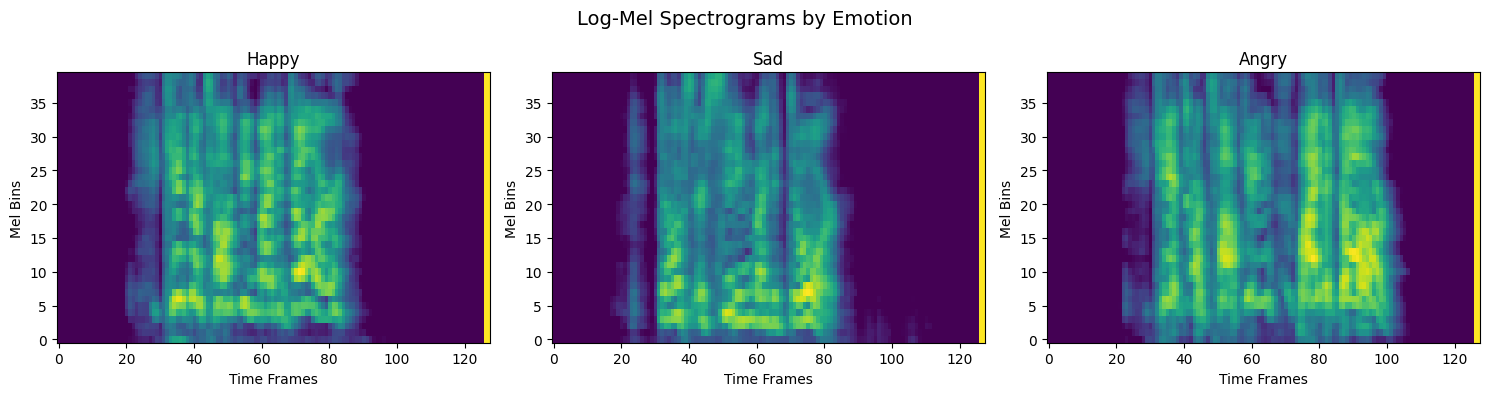

In [ ]:
import matplotlib.pyplot as plt

# Visualize sample spectrograms for each emotion
fig, axes = plt.subplots(1, len(target_classes), figsize=(15, 4))

for idx, emotion in enumerate(target_classes):
    # Find first sample of this emotion
    sample_idx = y.index(emotion)

    axes[idx].imshow(X[sample_idx, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
    axes[idx].set_title(f'{emotion.capitalize()}')
    axes[idx].set_xlabel('Time Frames')
    axes[idx].set_ylabel('Mel Bins')

plt.suptitle('Log-Mel Spectrograms by Emotion', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Label encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

# Split data (80% train, 20% test), stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Input shape: {X_train.shape[1:]}")

Label encoding:
  angry -> 0
  happy -> 1
  sad -> 2

Training set: 460 samples
Test set: 116 samples
Input shape: (40, 128, 1)


## 5. Build CNN Model

Architecture following the notes:
- Conv2D blocks with BatchNorm and MaxPooling
- Dropout for regularization
- Dense layers with softmax output

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def build_emotion_cnn(input_shape, num_classes):
    """
    Build CNN model for emotion classification from spectrograms.

    Architecture:
    - 3 Conv2D blocks with BatchNorm, ReLU, MaxPool, Dropout
    - Flatten -> Dense -> Output
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # Conv Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Build model
num_classes = len(le.classes_)
input_shape = X_train.shape[1:]

model = build_emotion_cnn(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,621,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,716,035 (10.36 MB)

 Trainable params: 2,715,587 (10.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Train the Model

In [ ]:
# Define callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 567ms/step - accuracy: 0.3151 - loss: 11.4231 - val_accuracy: 0.3276 - val_loss: 18.3627 - learning_rate: 0.0010
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 509ms/step - accuracy: 0.5014 - loss: 1.5562 - val_accuracy: 0.3276 - val_loss: 14.0917 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step - accuracy: 0.4280 - loss: 1.0284 - val_accuracy: 0.3276 - val_loss: 7.6759 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 585ms/step - accuracy: 0.4761 - loss: 1.0141 - val_accuracy: 0.3276 - val_loss: 3.7662 - learning_rate: 0.0010
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5515 - loss: 0.9654 - val_accuracy: 0.3276 - val_loss: 2.3242 - learning_rate: 0.0010
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 491ms/step - accuracy: 0.5356 - loss: 0.9127 - val_accuracy: 0.3276 - val_loss: 1.7933 - learning_rate: 0.0010
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 584ms/step - accuracy: 0.5813 - loss: 0.8464

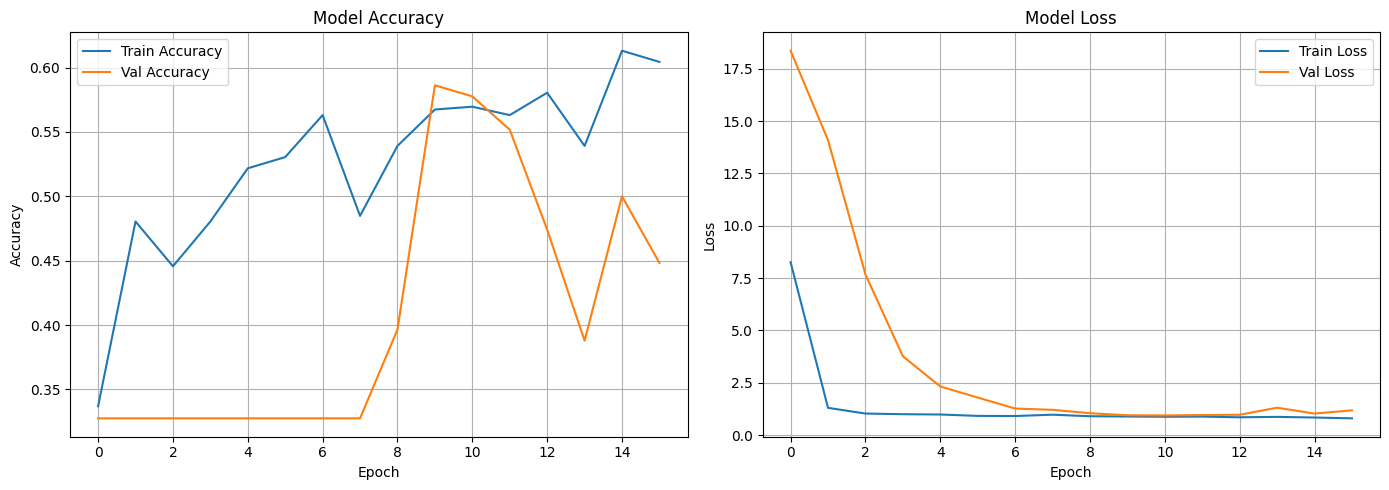

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluate Model Performance

In [ ]:
# Evaluate on test set
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.3f} ({score[1]*100:.1f}%)")
print(f"\nLabel mapping: {dict(zip(le.classes_, range(num_classes)))}")

Test Loss: 0.9385
Test Accuracy: 0.578 (57.8%)

Label mapping: {np.str_('angry'): 0, np.str_('happy'): 1, np.str_('sad'): 2}


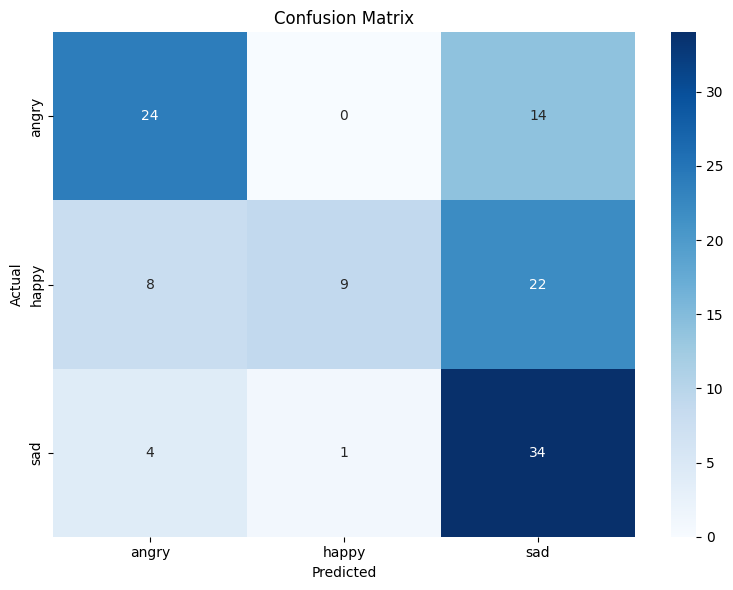


Classification Report:
              precision    recall  f1-score   support

       angry       0.67      0.63      0.65        38
       happy       0.90      0.23      0.37        39
         sad       0.49      0.87      0.62        39

    accuracy                           0.58       116
   macro avg       0.68      0.58      0.55       116
weighted avg       0.68      0.58      0.55       116



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

## 8. Privacy-Preserving Noise Injection

Add adaptive Laplacian noise to spectrograms to evaluate privacy-utility tradeoff.
Higher epsilon = less noise = more utility but less privacy.

In [ ]:
def adaptive_noise_logmel(logmel, weights, epsilon=20.0):
    """
    Add adaptive Laplacian noise to log-mel spectrogram for differential privacy.

    Args:
        logmel: 2D array (n_mels, time)
        weights: Per-frequency privacy weights (lower = more privacy)
        epsilon: Privacy budget (higher = less noise = less privacy)

    Returns:
        Noisy spectrogram
    """
    noisy = logmel.copy()
    for i in range(logmel.shape[0]):
        w = weights[i]
        # Scale noise based on data variance and privacy weight
        scale = (np.std(logmel[i]) + 1e-8) / (epsilon * (1 - w + 0.1))
        noise = np.random.laplace(0, scale, logmel.shape[1])
        noisy[i] += noise
    return noisy

# Define privacy weights (uniform for simplicity)
n_mels = X.shape[1]
weights = np.ones(n_mels) * 0.2  # Low privacy weight for all bins

print(f"Privacy weights shape: {weights.shape}")
print(f"Weight range: [{weights.min():.2f}, {weights.max():.2f}]")

Privacy weights shape: (40,)
Weight range: [0.20, 0.20]


In [ ]:
# Apply noise to all samples for training with noisy data
print("Injecting noise into all samples...")
X_noisy = []
for i in tqdm(range(len(X)), desc="Injecting noise"):
    logmel = X[i, :, :, 0]  # (n_mels, time)
    noisy = adaptive_noise_logmel(logmel, weights, epsilon=20.0)
    X_noisy.append(noisy)

X_noisy = np.stack(X_noisy)[..., np.newaxis]
print(f"Noisy data shape: {X_noisy.shape}")

Injecting noise into all samples...


Injecting noise:   0%|          | 0/576 [00:00<?, ?it/s]

Noisy data shape: (576, 40, 128, 1)


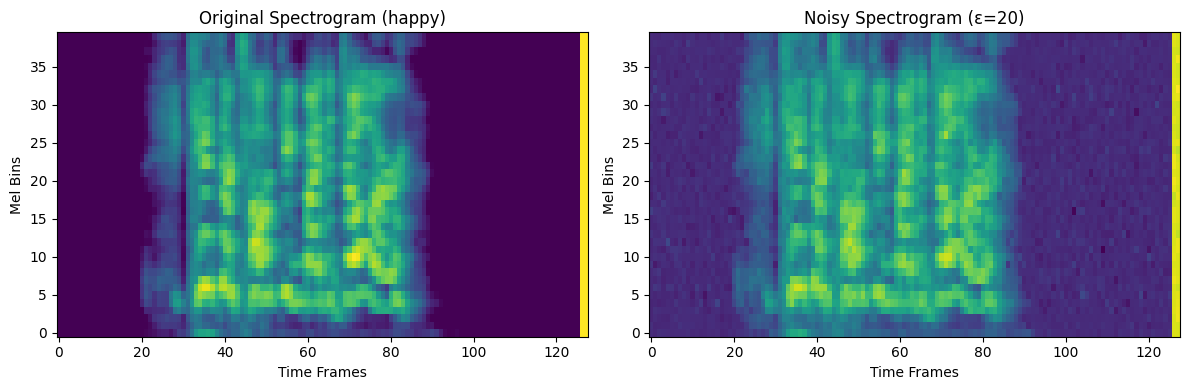

In [ ]:
# Visualize original vs noisy spectrogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample_idx = 0
axes[0].imshow(X[sample_idx, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title(f'Original Spectrogram ({y[sample_idx]})')
axes[0].set_xlabel('Time Frames')
axes[0].set_ylabel('Mel Bins')

axes[1].imshow(X_noisy[sample_idx, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title(f'Noisy Spectrogram (ε=20)')
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('Mel Bins')

plt.tight_layout()
plt.show()

In [ ]:
# Train model on noisy data
X_train_n, X_test_n, _, _ = train_test_split(
    X_noisy, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Clone the model architecture for training on noisy data
model_noisy = build_emotion_cnn(input_shape, num_classes)
model_noisy.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model on noisy data...")
history_noisy = model_noisy.fit(
    X_train_n, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test_n, y_test),
    verbose=1
)

# Evaluate noisy model
score_noisy = model_noisy.evaluate(X_test_n, y_test, verbose=0)
print(f"\n Noisy Model Test Accuracy: {score_noisy[1]:.3f}")

Training model on noisy data...
Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 627ms/step - accuracy: 0.3249 - loss: 12.4184 - val_accuracy: 0.3276 - val_loss: 13.0127
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 624ms/step - accuracy: 0.4104 - loss: 1.4232 - val_accuracy: 0.3276 - val_loss: 5.5752
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 523ms/step - accuracy: 0.5159 - loss: 0.9819 - val_accuracy: 0.3276 - val_loss: 3.5887
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 585ms/step - accuracy: 0.5144 - loss: 0.9650 - val_accuracy: 0.3276 - val_loss: 2.9866
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 618ms/step - accuracy: 0.5540 - loss: 0.9530 - val_accuracy: 0.3276 - val_loss: 2.0112
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 585ms/step - accuracy: 0.4944 - loss: 0.9800 - val_accuracy: 0.3276 - val_loss: 1.7509
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 499ms/step - accuracy: 0.5415 - loss: 0.9325 - val_accuracy: 0.3276 - val_loss: 1.4557
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 798ms/step - accuracy: 0.5

## 9. Privacy-Utility Tradeoff Analysis

Evaluate how different epsilon values affect model accuracy.

In [ ]:
# Test different privacy budgets (epsilon values)
epsilons = [5, 10, 20, 50, 100]
test_accs = []

print("Privacy-Utility Tradeoff Analysis")
print("=" * 50)
print("(Using clean-trained model on noisy test data)")
print()

for eps in epsilons:
    X_test_noisy = []
    for i in range(len(X_test)):
        logmel = X_test[i, :, :, 0]
        noisy = adaptive_noise_logmel(logmel, weights, epsilon=eps)
        X_test_noisy.append(noisy)
    X_test_noisy = np.stack(X_test_noisy)[..., np.newaxis]

    # Evaluate clean-trained model on noisy test data
    acc = model.evaluate(X_test_noisy, y_test, verbose=0)[1]
    print(f"ε={eps:3d}: Accuracy = {acc:.3f} | Privacy: {'High' if eps < 20 else 'Medium' if eps < 50 else 'Low'}")
    test_accs.append(acc)

print()
print("Note: Lower ε = more noise = better privacy but lower accuracy")

Privacy-Utility Tradeoff Analysis
(Using clean-trained model on noisy test data)

ε=  5: Accuracy = 0.379 | Privacy: High
ε= 10: Accuracy = 0.509 | Privacy: High
ε= 20: Accuracy = 0.578 | Privacy: Medium
ε= 50: Accuracy = 0.603 | Privacy: Low
ε=100: Accuracy = 0.595 | Privacy: Low

Note: Lower ε = more noise = better privacy but lower accuracy


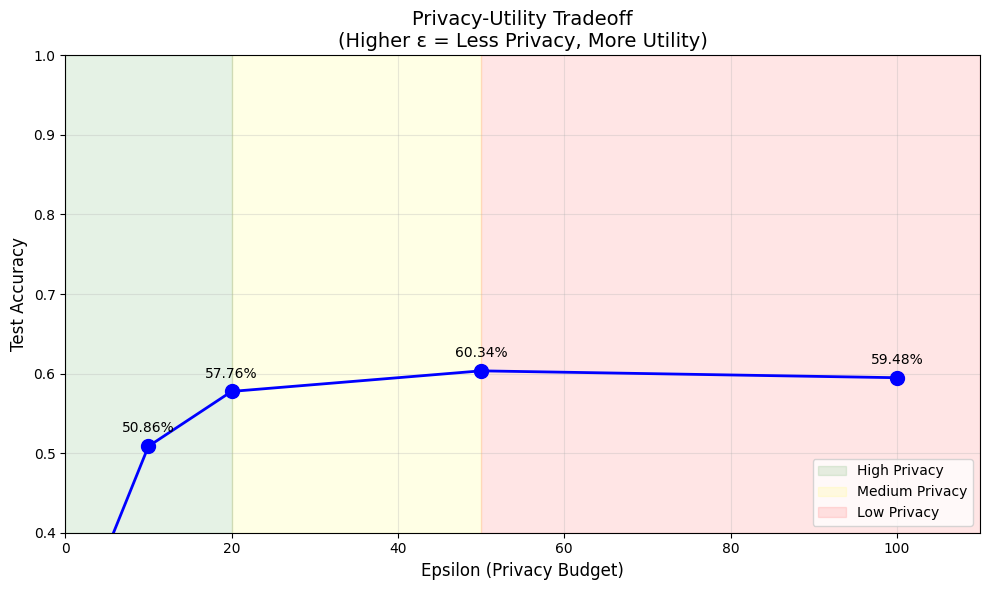

In [ ]:
# Plot Privacy-Utility Tradeoff
plt.figure(figsize=(10, 6))
plt.plot(epsilons, test_accs, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Epsilon (Privacy Budget)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Privacy-Utility Tradeoff\n(Higher ε = Less Privacy, More Utility)', fontsize=14)
plt.grid(True, alpha=0.3)

# Add annotations
for i, (eps, acc) in enumerate(zip(epsilons, test_accs)):
    plt.annotate(f'{acc:.2%}', (eps, acc), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10)

# Add privacy zone indicators
plt.axvspan(0, 20, alpha=0.1, color='green', label='High Privacy')
plt.axvspan(20, 50, alpha=0.1, color='yellow', label='Medium Privacy')
plt.axvspan(50, 110, alpha=0.1, color='red', label='Low Privacy')
plt.legend(loc='lower right')
plt.xlim(0, 110)
plt.ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

## 10. Save Model and Summary

In [ ]:
# Save the trained model
MODEL_PATH = os.path.join(DOWNLOAD_DIR, "emotion_cnn_model.keras")
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Save label encoder classes
import json
labels_path = os.path.join(DOWNLOAD_DIR, "emotion_labels.json")
with open(labels_path, 'w') as f:
    json.dump(list(le.classes_), f)
print(f"Labels saved to: {labels_path}")

# Print summary
print("\n" + "=" * 50)
print("EMOTION DETECTION MODEL SUMMARY")
print("=" * 50)
print(f"Dataset: RAVDESS")
print(f"Classes: {list(le.classes_)}")
print(f"Total Samples: {len(X)}")
print(f"Train/Test Split: {len(X_train)}/{len(X_test)}")
print(f"Input Shape: {input_shape}")
print(f"Clean Model Accuracy: {score[1]:.1%}")
print(f"Model Parameters: {model.count_params():,}")
print("=" * 50)

Model saved to: /root/Downloads/emotion_cnn_model.keras
Labels saved to: /root/Downloads/emotion_labels.json

EMOTION DETECTION MODEL SUMMARY
Dataset: RAVDESS
Classes: [np.str_('angry'), np.str_('happy'), np.str_('sad')]
Total Samples: 576
Train/Test Split: 460/116
Input Shape: (40, 128, 1)
Clean Model Accuracy: 57.8%
Model Parameters: 2,716,035


## ETHICAL ASSESSMENT
Proportionality & Do No Harm
1. Who are the intended users of your system, and what is their level of technical skill?
  - Marketing team phone calls / emergency lines, no experience

2. Is the AI system intended to be deployed in a critical sector such as energy, transportation,
water, health, digital infrastructure, finance, electoral systems, law enforcement or similar?
- yes (digital infrastructure, health, emergencies)

3. Is the AI system, including the core model, developed for this specific aim or objective or is it
built upon an existing model (e.g., GPT)? If so, please list relevant dependencies and
corresponding risks which may have an impact on the ethical impact assessment.
- developed for a specific objective, risks are generaizing specific situations

4. Has careful consideration been given to non-AI options which may be used to
achieve the
same goal? If so, why is the option involving an AI system favored?
- yes, other ideas have been considered but they did not manage to generalize well

5. Could other actors adapt the system for unethical uses, such as social scoring or mass
surveillance?
- nein

6. Will your system make decisions that could impact critical outcomes like someone's health,
safety, or legal status? (e.g., setting prison sentences or determining medical treatments).
- yes, mental health status

7. Could the AI system and its application impact fundamental human rights (e.g., human dignity,
freedom of expression, fair trial)?
- no

8. If the training data or data being processed by the AI system were poisoned or corrupted, or if
your system was manipulated, what would the consequences be?
Right to Privacy & Data Protection
- misjudgment, bias

9. If your data is people-centric: Is it anonymized?
- yes

10. Are users made aware of how their data is handled?
Fairness & Non-Discrimination
- nope

11. Does the data you're using for your project reflect a diverse range of users? If not, how might
this affect the fairness of the AI system?
- it is gender balanced

12. Has the algorithm been tested across diverse user groups? Were there differences in accuracy
or other performance metrics between groups? Did any results indicate potential bias or
discriminatory effects?
Human Oversight & Determination
- we did not test against different groups

13. Can users challenge or correct the AI's output? For example, if your AI system misclassifies
something or gives an incorrect recommendation, how can the user intervene?
Accountability & Responsibility
- they cannot do anything

14. In your project, who do you think should be responsible for decisions made by the AI?
- project owner

15. How would you assign accountability if the system makes a harmful or incorrect decision?
Transparency & Explainability
- on the entire company

16. Is there a risk that individuals impacted by the AI system are not made fully aware of when a
decision that impacted them was informed by or made on the basis of an AI system or AI
algorithms?
- yes

17. Can you clearly explain how the AI system makes its decisions? If a user asks, could you
provide a simple, understandable explanations?
- the algorithm learns the patterns from the combined data and tries to best generalize to the previous scenarios, it converts the sound into spectogram images and uses CNN to classify those prictures

Based on the answers to the questions above, what actions do you recommend?
- We would recommend re-analysing the group risks and biases so that it we could be sure that the algorithm is fair for all users.

